# Analyzing results after additional 5 day trials

In [2]:
import pandas as pd
import matplotlib as plt
import sklearn as sk
import matplotlib.pyplot as plt
from utilities import load_oura_data

                  timestamp  bpm source  skin_temp  spo2_percentage
0 2026-01-15 13:04:07+00:00  NaN    NaN      27.53              NaN
1 2026-01-15 13:06:06+00:00  NaN    NaN      28.14              NaN
2 2026-01-15 13:07:06+00:00  NaN    NaN      28.07              NaN
3 2026-01-15 13:08:06+00:00  NaN    NaN      27.88              NaN
4 2026-01-15 13:09:06+00:00  NaN    NaN      27.66              NaN
              timestamp  average_value  lower_bound  upper_bound  value
0  2026-03-26T00:00:00Z           94.9         93.6         96.7    NaN
1  2026-03-27T00:00:00Z           93.1         91.3         94.9    NaN
2  2026-03-28T00:00:00Z           94.2         92.0         96.9    NaN
3  2026-03-29T00:00:00Z           94.8         91.8         98.6    NaN
4  2026-03-30T00:00:00Z           94.3         92.9         96.4    NaN


# Load data and visualize the series

In [3]:
k_data = load_oura_data("k_Oura_29.4")



#add labels to data
# add data labels to the data frame
# 7.2.-13.2.2026 24.2-27.2.2026 7.3.-14.3.2026 1.4.-8.4.2026

utc = "UTC"
intervals = [ #when rcn is used
    (pd.Timestamp("2026-02-07", tz=utc), pd.Timestamp("2026-02-13", tz=utc)),
    (pd.Timestamp("2026-02-24", tz=utc), pd.Timestamp("2026-02-27", tz=utc)),
    (pd.Timestamp("2026-03-07", tz=utc), pd.Timestamp("2026-03-14", tz=utc)),
    (pd.Timestamp("2026-04-01", tz=utc), pd.Timestamp("2026-04-08", tz=utc)),
    (pd.Timestamp("2026-04-24", tz=utc), pd.Timestamp("2026-04-29", tz=utc)),
]

def generate_labels(timestamp): # label 1 used rcn
    for start, end in intervals:
        if start <= timestamp <= end:
            return 1
    return 0
    
k_data["label"] = k_data["timestamp"].apply(generate_labels)
k_data.head()
k_data.to_csv("oura_merged_data.csv", index=False)


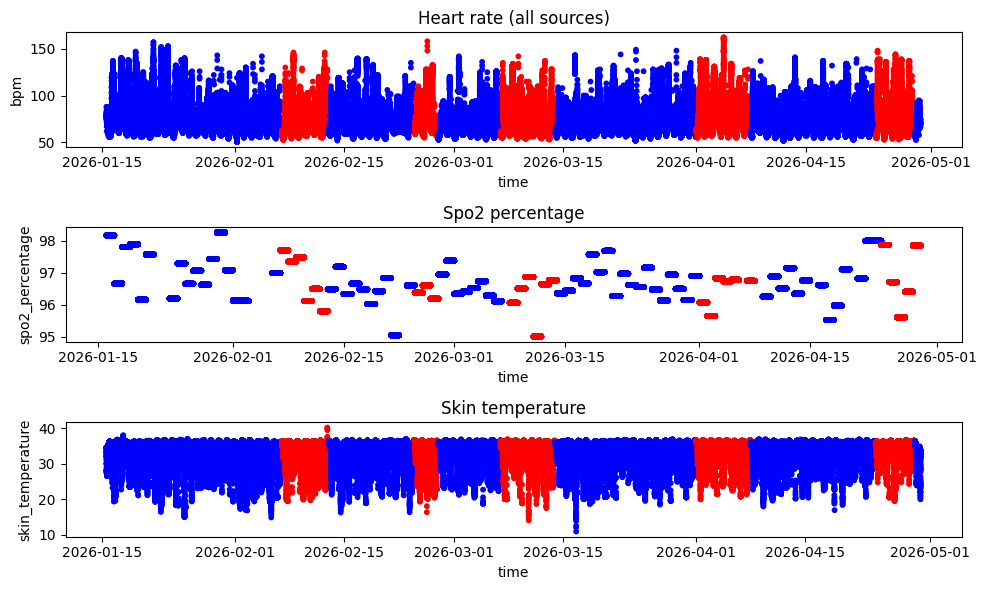

In [10]:
# Visualize the data
# color the data points based on the label
label_colors = k_data["label"].map({0: "blue", 1: "red"}).tolist()
#est_label_colors = k_data_rest["label"].map({0: "blue", 1: "red"}).tolist()

fig, axs = plt.subplots(3, 1, figsize=(10, 6))

axs[0].scatter(k_data["timestamp"], k_data["bpm"], c=label_colors, s=10)
axs[0].set_xlabel("time")
axs[0].set_ylabel("bpm")
axs[0].set_title("Heart rate (all sources)")

axs[1].scatter(k_data["timestamp"], k_data["spo2_percentage"], c=label_colors, s=10)
axs[1].set_xlabel("time")
axs[1].set_ylabel("spo2_percentage")
axs[1].set_title("Spo2 percentage")

axs[2].scatter(k_data["timestamp"], k_data["skin_temp"], c=label_colors, s=10)
axs[2].set_xlabel("time")
axs[2].set_ylabel("skin_temperature")
axs[2].set_title("Skin temperature")

fig.tight_layout()

# Test bpm for statistical difference

Mann whitney U test


Label 1 (RCN) samples after resampling : 116638
Label 0 (control) samples after resampling: 150073

Aligned length (samples): 116638
Approx. duration at 1min resolution: 116638 minutes = 1944.0 hours

Difference series  mean : -4.40 bpm
Difference series  std  : 15.60 bpm


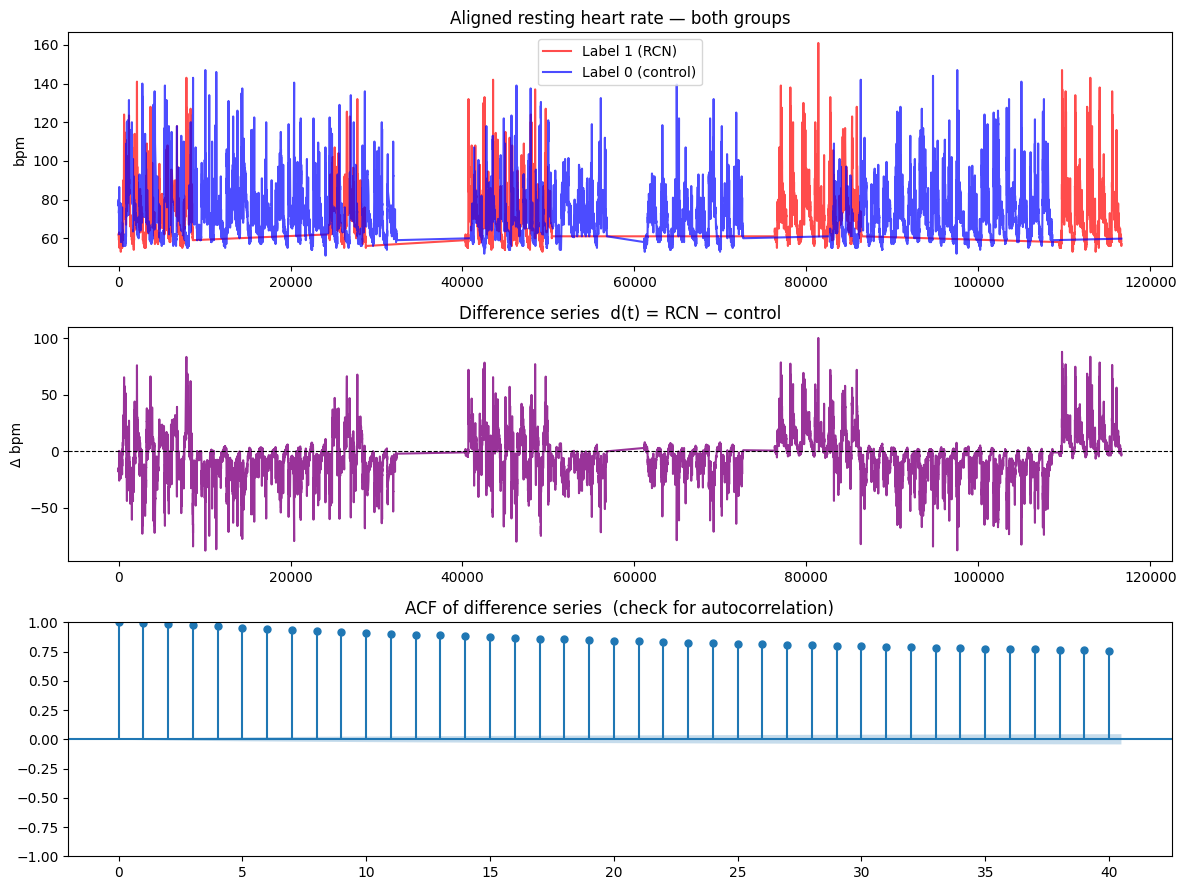


--- Alignment complete ---
Use  g1, g0  for the aligned individual series.
Use  d       for the difference series in Step 2 (GLS / permutation test).


In [11]:
data = k_data.copy()  # work on a copy to preserve original data if needed
# =============================================================================
# STEP 1: Align label groups to a common time grid before comparison
# =============================================================================
# The two label groups span different calendar periods and have different
# lengths. We resample each to a regular 1-minute grid, then trim both
# to equal length so the difference series d(t) = label1(t) - label0(t)
# is well-defined for time-series methods.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

RESAMPLE_FREQ = "1min"   # change to "5min" if data is sparse

# --- 1a. Separate the two groups (rest source only, same as before) ----------
g1_raw = data[data["label"] == 1][["timestamp", "bpm"]].copy()
g0_raw = data[data["label"] == 0][["timestamp", "bpm"]].copy()

# --- 1b. Resample each group to a regular grid using median per bin ----------
# Using median instead of mean makes this robust to short spikes in HR data.
def to_regular_grid(df, freq=RESAMPLE_FREQ):
    df = df.set_index("timestamp").sort_index()
    resampled = df["bpm"].resample(freq).median()
    resampled = resampled.interpolate(method="time")   # fill any empty bins
    resampled = resampled.dropna()
    # Reset to relative integer index so groups align positionally,
    # not by wall-clock time.
    resampled = resampled.reset_index(drop=True)
    return resampled

g1 = to_regular_grid(g1_raw)
g0 = to_regular_grid(g0_raw)

print(f"Label 1 (RCN) samples after resampling : {len(g1)}")
print(f"Label 0 (control) samples after resampling: {len(g0)}")

# --- 1c. Trim both series to the same length ---------------------------------
min_len = min(len(g1), len(g0))
g1 = g1.iloc[:min_len]
g0 = g0.iloc[:min_len]

print(f"\nAligned length (samples): {min_len}")
print(f"Approx. duration at {RESAMPLE_FREQ} resolution: "
      f"{min_len} minutes = {min_len/60:.1f} hours")

# --- 1d. Compute the difference series ---------------------------------------
d = g1.values - g0.values          # d(t) = HR_rcn(t) - HR_control(t)

print(f"\nDifference series  mean : {d.mean():.2f} bpm")
print(f"Difference series  std  : {d.std():.2f} bpm")

# --- 1e. Visual diagnostics --------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(12, 9))

axs[0].plot(g1.values, color="red",  alpha=0.7, label="Label 1 (RCN)")
axs[0].plot(g0.values, color="blue", alpha=0.7, label="Label 0 (control)")
axs[0].set_ylabel("bpm")
axs[0].set_title("Aligned resting heart rate — both groups")
axs[0].legend()

axs[1].plot(d, color="purple", alpha=0.8)
axs[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axs[1].set_ylabel("Δ bpm")
axs[1].set_title("Difference series  d(t) = RCN − control")

plot_acf(d, ax=axs[2], lags=min(40, min_len // 2 - 1))
axs[2].set_title("ACF of difference series  (check for autocorrelation)")

fig.tight_layout()
plt.show()

# --- Summary for next step ---------------------------------------------------
print("\n--- Alignment complete ---")
print("Use  g1, g0  for the aligned individual series.")
print("Use  d       for the difference series in Step 2 (GLS / permutation test).")

RCN days     : 28
Control days : 77

RCN     median: 86.0 bpm  (IQR 82.0–89.0)
Control median: 85.0 bpm  (IQR 78.0–90.0)

Mann-Whitney U : 1129.5
p-value        : 0.7113
Effect size r  : -0.048  (|r|>0.1 small, >0.3 medium, >0.5 large)
→ No significant difference detected (p ≥ 0.05)


C:\Users\henri\AppData\Local\Temp\ipykernel_12452\1994230841.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot([g0_daily, g1_daily], labels=["Control", "RCN"], patch_artist=True,


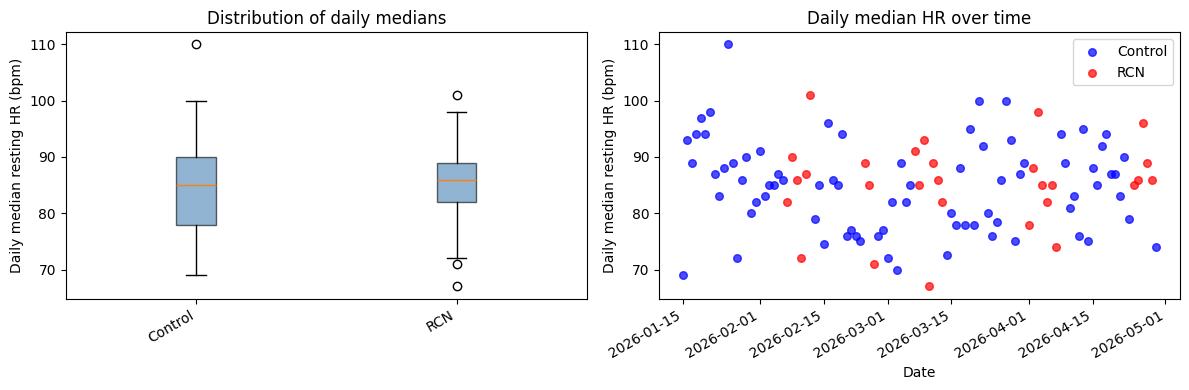

In [12]:
# =============================================================================
# STEP 3 (revised): Compare daily median resting HR between groups
# =============================================================================
# Aggregate to one value per day per group, then use a Mann-Whitney U test.
# Daily medians are approximately independent, removing the autocorrelation
# problem entirely. No alignment needed — each day stands on its own.

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# --- 3a. Daily median resting HR per label -----------------------------------
daily = (data
         .groupby([data["timestamp"].dt.date, "label"])["bpm"]
         .median()
         .reset_index())
daily.columns = ["date", "label", "median_bpm"]

g1_daily = daily[daily["label"] == 1]["median_bpm"].values
g0_daily = daily[daily["label"] == 0]["median_bpm"].values

print(f"RCN days     : {len(g1_daily)}")
print(f"Control days : {len(g0_daily)}")
print(f"\nRCN     median: {np.median(g1_daily):.1f} bpm  (IQR {np.percentile(g1_daily,25):.1f}–{np.percentile(g1_daily,75):.1f})")
print(f"Control median: {np.median(g0_daily):.1f} bpm  (IQR {np.percentile(g0_daily,25):.1f}–{np.percentile(g0_daily,75):.1f})")

# --- 3b. Mann-Whitney U test --------------------------------------------------
# Non-parametric, no normality assumption, works on small samples,
# and daily medians are reasonably independent.
stat, p_value = stats.mannwhitneyu(g1_daily, g0_daily, alternative="two-sided")
r = 1 - (2 * stat) / (len(g1_daily) * len(g0_daily))  # rank-biserial correlation (effect size)

print(f"\nMann-Whitney U : {stat:.1f}")
print(f"p-value        : {p_value:.4f}")
print(f"Effect size r  : {r:+.3f}  (|r|>0.1 small, >0.3 medium, >0.5 large)")

if p_value < 0.05:
    print("→ Significant difference between RCN and control days (p < 0.05)")
else:
    print("→ No significant difference detected (p ≥ 0.05)")

# --- 3c. Plot ----------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
axs[0].boxplot([g0_daily, g1_daily], labels=["Control", "RCN"], patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
axs[0].set_ylabel("Daily median resting HR (bpm)")
axs[0].set_title("Distribution of daily medians")

# Daily values over time
rcn_dates  = daily[daily["label"] == 1]["date"]
ctrl_dates = daily[daily["label"] == 0]["date"]
axs[1].scatter(ctrl_dates, g0_daily, color="blue", alpha=0.7, label="Control", s=30)
axs[1].scatter(rcn_dates,  g1_daily, color="red",  alpha=0.7, label="RCN",     s=30)
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Daily median resting HR (bpm)")
axs[1].set_title("Daily median HR over time")
axs[1].legend()
fig.autofmt_xdate()

fig.tight_layout()
plt.show()

# Difference for spo2 

Label 1 (RCN) samples after resampling : 23328
Label 0 (control) samples after resampling: 28224

Aligned length (samples): 23328
Approx. duration at 5min resolution: 23328 minutes = 388.8 hours

Difference series  mean : -0.11 spo2_percentage
Difference series  std  : 0.77 spo2_percentage


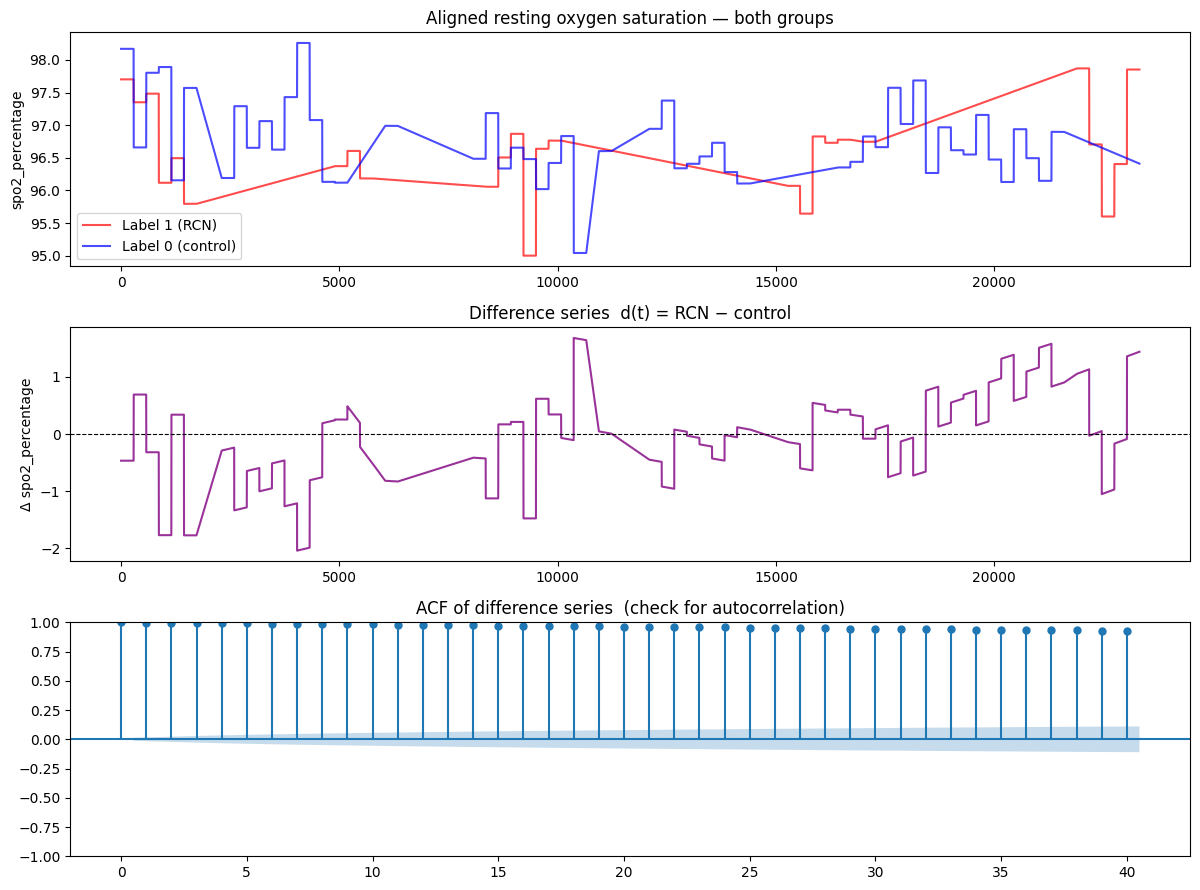


--- Alignment complete ---
Use  g1, g0  for the aligned individual series.
Use  d       for the difference series in Step 2 (GLS / permutation test).


In [17]:
data = k_data.copy()
#filter na values
data = data.dropna(subset=[ "spo2_percentage" ])

# =============================================================================
# STEP 1: Align label groups to a common time grid before comparison
# =============================================================================
# The two label groups span different calendar periods and have different
# lengths. We resample each to a regular 1-minute grid, then trim both
# to equal length so the difference series d(t) = label1(t) - label0(t)
# is well-defined for time-series methods.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

RESAMPLE_FREQ = "5min"   # change to "5min" if data is sparse

# --- 1a. Separate the two groups (rest source only, same as before) ----------
g1_raw = data[data["label"] == 1][["timestamp", "spo2_percentage"]].copy()
g0_raw = data[data["label"] == 0][["timestamp", "spo2_percentage"]].copy()

# --- 1b. Resample each group to a regular grid using median per bin ----------
# Using median instead of mean makes this robust to short spikes in HR data.
def to_regular_grid(df, freq=RESAMPLE_FREQ):
    df = df.set_index("timestamp").sort_index()
    resampled = df["spo2_percentage"].resample(freq).median()
    resampled = resampled.interpolate(method="time")   # fill any empty bins
    resampled = resampled.dropna()
    # Reset to relative integer index so groups align positionally,
    # not by wall-clock time.
    resampled = resampled.reset_index(drop=True)
    return resampled

g1 = to_regular_grid(g1_raw)
g0 = to_regular_grid(g0_raw)

print(f"Label 1 (RCN) samples after resampling : {len(g1)}")
print(f"Label 0 (control) samples after resampling: {len(g0)}")

# --- 1c. Trim both series to the same length ---------------------------------
min_len = min(len(g1), len(g0))
g1 = g1.iloc[:min_len]
g0 = g0.iloc[:min_len]

print(f"\nAligned length (samples): {min_len}")
print(f"Approx. duration at {RESAMPLE_FREQ} resolution: "
      f"{min_len} minutes = {min_len/60:.1f} hours")

# --- 1d. Compute the difference series ---------------------------------------
d = g1.values - g0.values          # d(t) = HR_rcn(t) - HR_control(t)

print(f"\nDifference series  mean : {d.mean():.2f} spo2_percentage")
print(f"Difference series  std  : {d.std():.2f} spo2_percentage")

# --- 1e. Visual diagnostics --------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(12, 9))

axs[0].plot(g1.values, color="red",  alpha=0.7, label="Label 1 (RCN)")
axs[0].plot(g0.values, color="blue", alpha=0.7, label="Label 0 (control)")
axs[0].set_ylabel("spo2_percentage")
axs[0].set_title("Aligned resting oxygen saturation — both groups")
axs[0].legend()

axs[1].plot(d, color="purple", alpha=0.8)
axs[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axs[1].set_ylabel("Δ spo2_percentage")
axs[1].set_title("Difference series  d(t) = RCN − control")

plot_acf(d, ax=axs[2], lags=min(40, min_len // 2 - 1))
axs[2].set_title("ACF of difference series  (check for autocorrelation)")

fig.tight_layout()
plt.show()

# --- Summary for next step ---------------------------------------------------
print("\n--- Alignment complete ---")
print("Use  g1, g0  for the aligned individual series.")
print("Use  d       for the difference series in Step 2 (GLS / permutation test).")

RCN days     : 26
Control days : 66

RCN     median: 96.6 %  (IQR 96.1–96.8)
Control median: 96.7 %  (IQR 96.3–97.1)

Mann-Whitney U : 736.0
p-value        : 0.2921
Effect size r  : +0.142  (|r|>0.1 small, >0.3 medium, >0.5 large)
→ No significant difference detected (p ≥ 0.05)


C:\Users\henri\AppData\Local\Temp\ipykernel_12452\2209002016.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot([g0_daily, g1_daily], labels=["Control", "RCN"], patch_artist=True,


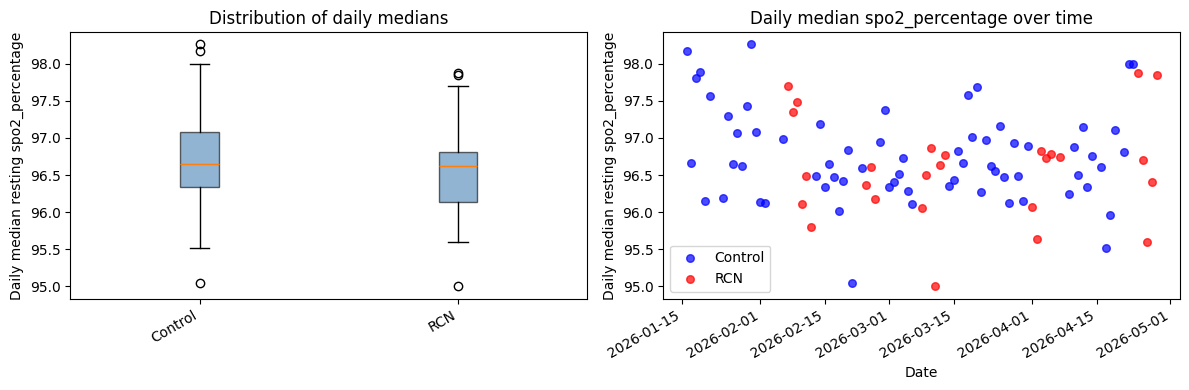

In [18]:
# =============================================================================
# STEP 3 (revised): Compare daily median resting HR between groups
# =============================================================================
# Aggregate to one value per day per group, then use a Mann-Whitney U test.
# Daily medians are approximately independent, removing the autocorrelation
# problem entirely. No alignment needed — each day stands on its own.

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# --- 3a. Daily median resting HR per label -----------------------------------
daily = (data
         .groupby([data["timestamp"].dt.date, "label"])["spo2_percentage"]
         .median()
         .reset_index())
daily.columns = ["date", "label", "median_spo2_percentage"]
    
g1_daily = daily[daily["label"] == 1]["median_spo2_percentage"].values
g0_daily = daily[daily["label"] == 0]["median_spo2_percentage"].values

print(f"RCN days     : {len(g1_daily)}")
print(f"Control days : {len(g0_daily)}")
print(f"\nRCN     median: {np.median(g1_daily):.1f} %  (IQR {np.percentile(g1_daily,25):.1f}–{np.percentile(g1_daily,75):.1f})")
print(f"Control median: {np.median(g0_daily):.1f} %  (IQR {np.percentile(g0_daily,25):.1f}–{np.percentile(g0_daily,75):.1f})")

# --- 3b. Mann-Whitney U test --------------------------------------------------
# Non-parametric, no normality assumption, works on small samples,
# and daily medians are reasonably independent.
stat, p_value = stats.mannwhitneyu(g1_daily, g0_daily, alternative="two-sided")
r = 1 - (2 * stat) / (len(g1_daily) * len(g0_daily))  # rank-biserial correlation (effect size)

print(f"\nMann-Whitney U : {stat:.1f}")
print(f"p-value        : {p_value:.4f}")
print(f"Effect size r  : {r:+.3f}  (|r|>0.1 small, >0.3 medium, >0.5 large)")

if p_value < 0.05:
    print("→ Significant difference between RCN and control days (p < 0.05)")
else:
    print("→ No significant difference detected (p ≥ 0.05)")

# --- 3c. Plot ----------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
axs[0].boxplot([g0_daily, g1_daily], labels=["Control", "RCN"], patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
axs[0].set_ylabel("Daily median resting spo2_percentage")
axs[0].set_title("Distribution of daily medians")

# Daily values over time
rcn_dates  = daily[daily["label"] == 1]["date"]
ctrl_dates = daily[daily["label"] == 0]["date"]
axs[1].scatter(ctrl_dates, g0_daily, color="blue", alpha=0.7, label="Control", s=30)
axs[1].scatter(rcn_dates,  g1_daily, color="red",  alpha=0.7, label="RCN",     s=30)
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Daily median resting spo2_percentage")
axs[1].set_title("Daily median spo2_percentage over time")
axs[1].legend()
fig.autofmt_xdate()

fig.tight_layout()
plt.show()

In [16]:
print(np.mean(k_data["spo2_percentage"]))

96.70460925927469
